KNN - Best Plant Accuracy: 98.18%, Best Fertilizer Accuracy: 87.05%


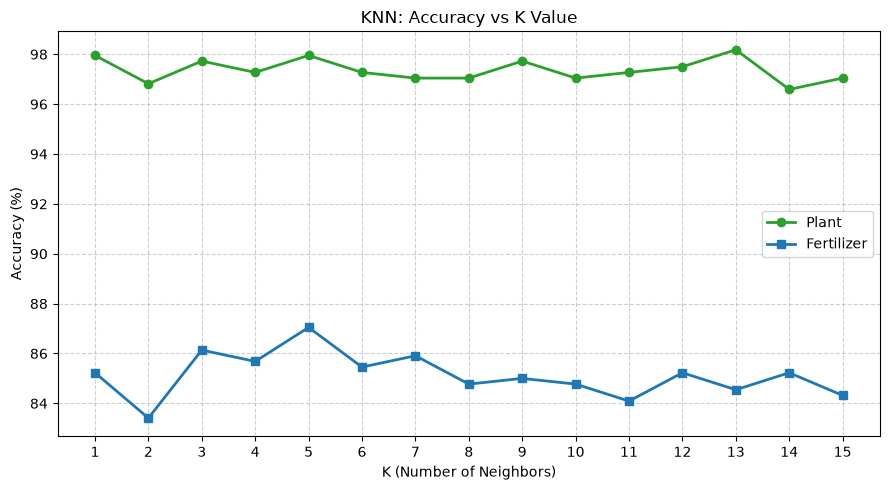

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# --- ข้อมูลที่ 1: ทำนายพืช (Plant.csv) ---
df_plant = pd.read_csv('Plant.csv')
features_plant = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X_p = df_plant[features_plant]
y_p = df_plant['label']
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

# --- ข้อมูลที่ 2: ทำนายปุ๋ย (Fertilizer.csv) ---
df_fert = pd.read_csv('Fertilizer.csv')
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
cat_cols = ['label']
X_f = df_fert[num_cols + cat_cols]
y_f = df_fert['fertilizer']
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ทดสอบค่า K จาก 1 ถึง 15 ทั้งสองโมเดล
k_range = range(1, 16)
plant_accs, fert_accs = [], []

for k in k_range:
    m_p = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=k))])
    m_p.fit(X_p_train, y_p_train)
    plant_accs.append(accuracy_score(y_p_test, m_p.predict(X_p_test)) * 100)

    m_f = Pipeline([('prep', preprocessor), ('knn', KNeighborsClassifier(n_neighbors=k))])
    m_f.fit(X_f_train, y_f_train)
    fert_accs.append(accuracy_score(y_f_test, m_f.predict(X_f_test)) * 100)

print(f"KNN - Best Plant Accuracy: {max(plant_accs):.2f}%, Best Fertilizer Accuracy: {max(fert_accs):.2f}%")

# --- พล็อตกราฟเปรียบเทียบค่า K สำหรับทั้งสองชุดข้อมูล ---
plt.figure(figsize=(9, 5))
plt.plot(k_range, plant_accs, marker='o', label='Plant', color='#2ca02c', linewidth=2)
plt.plot(k_range, fert_accs, marker='s', label='Fertilizer', color='#1f77b4', linewidth=2)
plt.title('KNN: Accuracy vs K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy (%)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()